In [1]:
from xaikd import models, datasets, utils
from xaikd.utils import metrics

import numpy as np
from matplotlib import pyplot as plt

/home/pat/projects/xai-kd/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def compute_acc(model_name, dataset_name):
    dataset = datasets.construct(dataset_name)
    model = models.get_trained_model(model_name)
    utils.modify_last_layer_for_subclasses(model, dataset.selected_classes)
    
    ds = dataset.create_subset(train_split=False)
    dl = datasets.build_dataloader(ds, shuffle=False)
    
    acc, _ = metrics.accuracy(model=model, dataloader=dl, num_classes=len(dataset.selected_classes), device="cpu")

#     print(f"[model={model_name}, dataset={dataset_name} (num_classes={len(dataset.selected_classes)})] acc={acc:.4f}")
    return len(dataset.selected_classes), acc 
compute_acc("imagenet-resnet18-tv", "imagenet-butterfly")

We have 300 images in classes [321, 322, 323, 324, 325, 326]


Preparing `ImageNetSuperClass[[321, 322, 323, 324, 325, 326]]` samples: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 2211408.08it/s]


(6, 0.9666666388511658)

We have 300 images in classes [472, 554, 576, 625, 814, 914]


Preparing `ImageNetSuperClass[[472, 554, 576, 625, 814, 914]]` samples: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 2188332.52it/s]


We have 300 images in classes [321, 322, 323, 324, 325, 326]


Preparing `ImageNetSuperClass[[321, 322, 323, 324, 325, 326]]` samples: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 2250968.16it/s]


We have 500 images in classes [407, 436, 468, 511, 609, 627, 656, 661, 751, 817]


...

Preparing `ImageNetSuperClass[[948, 949, 950, 951, 952, 953, 954, 955, 956, 957]]` samples: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 2307097.91it/s]


We have 300 images in classes [991, 993, 994, 995, 996, 997]


Preparing `ImageNetSuperClass[[991, 993, 994, 995, 996, 997]]` samples: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 2300349.54it/s]


We have 400 images in classes [555, 569, 656, 675, 717, 734, 864, 867]


Preparing `ImageNetSuperClass[[555, 569, 656, 675, 717, 734, 864, 867]]` samples: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:00<00:00, 2033601.94it/s]


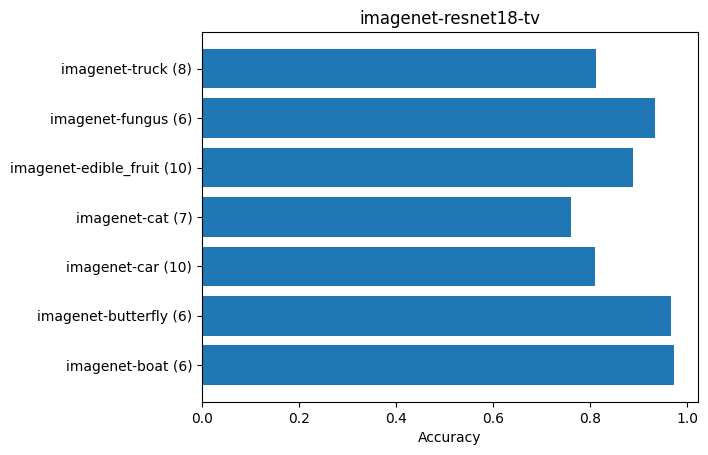

In [3]:
def viz(model_name):
    
    
    arr_accs = []
    arr_numclasses = []
    arr_dataset_names = [
        "imagenet-boat",
        "imagenet-butterfly",
        "imagenet-car",
        "imagenet-cat",
        "imagenet-edible_fruit",
        "imagenet-fungus",
        "imagenet-truck",
    ]
    
    
    for dix, dataset_name in enumerate(arr_dataset_names):
        num_classes, acc  = compute_acc(model_name, dataset_name)
        arr_accs.append(acc)
        arr_numclasses.append(num_classes)
    
    
    plt.title(model_name)
    ticks = np.arange(len(arr_dataset_names))
    plt.barh(
        ticks,
        arr_accs
    )
    
    plt.yticks(
        ticks, 
        list(map(lambda x: f"{x[0]} ({x[1]})", zip(arr_dataset_names, arr_numclasses)))
    )
    plt.xlabel("Accuracy")
    
viz("imagenet-resnet18-tv")

In [4]:
for teacher_model in [
    "imagenet-resnet50-tv",
    "imagenet-vgg16-tv",
    "imagenet-nfnetf0-dm",
    "imagenet-vitb-tv",
]:
    viz(teacher_model)

We have 300 images in classes [472, 554, 576, 625, 814, 914]


Preparing `ImageNetSuperClass[[472, 554, 576, 625, 814, 914]]` samples: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 2086718.41it/s]


KeyboardInterrupt: 